# 🌿 VedaVision — Module 2
# Notebook 05 — Classification
### Compare Models → Tune Best → Evaluate on Held-Out Test Set

---
**Input**  : `dataset/csv/species_id_train_features.csv`
             `dataset/csv/species_id_test_features.csv`
             `dataset/csv/species_id_test_labels.csv`

**Output** : `dataset/models/species_classifier.pkl`
             `dataset/models/scaler.pkl`
             `dataset/models/label_encoder.pkl`
             `dataset/models/feature_columns.pkl`
             `dataset/logs/05_*.png` (evaluation charts)

---
### Pipeline:
```
Train CSV (97 features + species label)
      |
  1.  Clean data           -> check/handle NaN & Inf (Gabor/GLCM can
                               occasionally produce these on edge-case images)
  2.  Encode labels         -> species name -> integer
  3.  Train/validation split -> stratified, so class balance is preserved
  4.  Scale features        -> StandardScaler (needed for SVM/KNN/LogReg,
                               harmless for tree models)
  5.  Compare 6 candidate models with 5-fold cross-validation:
        Random Forest, Gradient Boosting, XGBoost, SVM (RBF),
        Logistic Regression, K-Nearest Neighbors
  6.  Feature importance    -> which of the 97 features actually separate
                               your species (useful for the morphologically
                               similar Sudu/Rathu Koboleela pair specifically)
  7.  Hyperparameter-tune the best-performing model (GridSearchCV)
  8.  Refit on the FULL training set for the final deployable model
  9.  Predict on the TRUE test set (features only, no labels)
  10. Score against the hidden true labels -> final accuracy
  11. Per-species + per-view breakdown, and confusion pairs
  12. Save model + scaler + label encoder for later inference
```
---
### Run Order:
```
01_Augmentation -> 02_Preprocessing -> 04_Feature_Extraction -> 05_Classification.ipynb  (this notebook)
```
---
### A note on this specific dataset
Two of your species (Sudu_Koboleela / Rathu_Koboleela) are morphologically
similar by design -- that is exactly the case this notebook is built to
stress-test. The per-species accuracy and confusion-pair sections (Cell 14)
will tell you directly whether the 97 features actually separate this pair,
rather than just reporting one overall accuracy number that could hide a
weak spot.


## Cell 1 — Install Libraries

In [2]:
!pip install scikit-learn xgboost joblib matplotlib seaborn pandas numpy -q
print('✅ Libraries installed!')

✅ Libraries installed!


## Cell 2 — Import Libraries

In [4]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from google.colab import drive

print('✅ All libraries imported!')

✅ All libraries imported!


## Cell 3 — Mount Drive & Configure Paths
**Only change things in this cell**

In [5]:
drive.mount('/content/drive')

# ============================================================
# ✏️  UPDATE THESE PATHS — match your feature extraction notebook
# ============================================================
CSV_PATH   = '/content/drive/MyDrive/VedaVision/dataset/csv'
MODEL_PATH = '/content/drive/MyDrive/VedaVision/dataset/models'
LOGS_PATH  = '/content/drive/MyDrive/VedaVision/dataset/logs'

TRAIN_CSV       = os.path.join(CSV_PATH, 'species_id_train_features.csv')
TEST_CSV        = os.path.join(CSV_PATH, 'species_id_test_features.csv')
TEST_LABELS_CSV = os.path.join(CSV_PATH, 'species_id_test_labels.csv')

RANDOM_STATE = 42
VAL_SIZE     = 0.2   # fraction of TRAIN held out for validation during model selection
# ============================================================

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(LOGS_PATH,  exist_ok=True)

print(f'✅ Drive mounted!')
print(f'📁 CSV input    : {CSV_PATH}')
print(f'📁 Model output : {MODEL_PATH}')

Mounted at /content/drive
✅ Drive mounted!
📁 CSV input    : /content/drive/MyDrive/VedaVision/dataset/csv
📁 Model output : /content/drive/MyDrive/VedaVision/dataset/models


## Cell 4 — Load Train / Test CSVs

In [6]:
train_df       = pd.read_csv(TRAIN_CSV)
test_df        = pd.read_csv(TEST_CSV)
test_labels_df = pd.read_csv(TEST_LABELS_CSV)

print('📊 TRAIN features :', train_df.shape)
print('📊 TEST features  :', test_df.shape)
print('📊 TEST labels    :', test_labels_df.shape)
print()
print('Species in train:', sorted(train_df['species'].unique()))
print()
print('Images per species/view (train):')
print(train_df.groupby(['species', 'view']).size().to_string())

📊 TRAIN features : (1080, 101)
📊 TEST features  : (20, 99)
📊 TEST labels    : (20, 3)

Species in train: ['Rathu_Koboleela', 'Sudu_Koboleela']

Images per species/view (train):
species          view  
Rathu_Koboleela  bottom    270
                 top       270
Sudu_Koboleela   bottom    270
                 top       270


## Cell 5 — Prepare Features & Labels

- Drops non-feature columns (filename/species/view/label)
- Adds `view` back in as a one-hot feature (top vs bottom is a real,
  reproducible signal — you always know which surface a photo shows,
  unlike camera distance, which isn't reproducible at inference time)
- Checks for NaN/Inf (GLCM/Gabor can occasionally produce these on a
  near-empty or degenerate mask) and cleans them
- Encodes species names to integers for the classifier

In [7]:
META_COLS = ['filename', 'species', 'view', 'label']
feature_cols = [c for c in train_df.columns if c not in META_COLS]

X = train_df[feature_cols].copy()
X['view_top'] = (train_df['view'] == 'top').astype(int)
feature_cols_final = feature_cols + ['view_top']

y = train_df['label'].copy()

# Check for NaN / Inf
n_nan = X.isna().sum().sum()
n_inf = np.isinf(X.select_dtypes(include=[np.number]).values).sum()
print(f'NaN values found: {n_nan}')
print(f'Inf values found: {n_inf}')

if n_nan > 0 or n_inf > 0:
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))
    print('✅ Cleaned: Inf -> NaN -> filled with column median')

train_medians = X.median(numeric_only=True)  # saved for cleaning the test set the same way later

# Encode species labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print()
print('Classes:', list(label_encoder.classes_))
print()
print('Class counts:')
print(y.value_counts())
print()
print(f'Total feature columns (incl. view_top): {len(feature_cols_final)}')

NaN values found: 0
Inf values found: 0

Classes: ['Rathu_Koboleela', 'Sudu_Koboleela']

Class counts:
label
Rathu_Koboleela    540
Sudu_Koboleela     540
Name: count, dtype: int64

Total feature columns (incl. view_top): 98


## Cell 6 — Train / Validation Split + Feature Scaling

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded,
    test_size=VAL_SIZE,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f'Train: {X_train.shape[0]} samples')
print(f'Val  : {X_val.shape[0]} samples')

Train: 864 samples
Val  : 216 samples


## Cell 7 — Compare Candidate Models (5-fold Cross-Validation)

Runs each model on the TRAINING split only (validation set stays untouched
until Cell 10), so this comparison is unbiased.

🔬 5-fold cross-validation on TRAINING split
Random Forest          mean=1.0000  std=0.0000
Gradient Boosting      mean=1.0000  std=0.0000
XGBoost                mean=1.0000  std=0.0000
SVM (RBF)              mean=1.0000  std=0.0000
Logistic Regression    mean=1.0000  std=0.0000
K-Nearest Neighbors    mean=1.0000  std=0.0000

🏆 Best model by CV: Random Forest


/tmp/ipykernel_1395/1784585448.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_results.values(), labels=cv_results.keys())


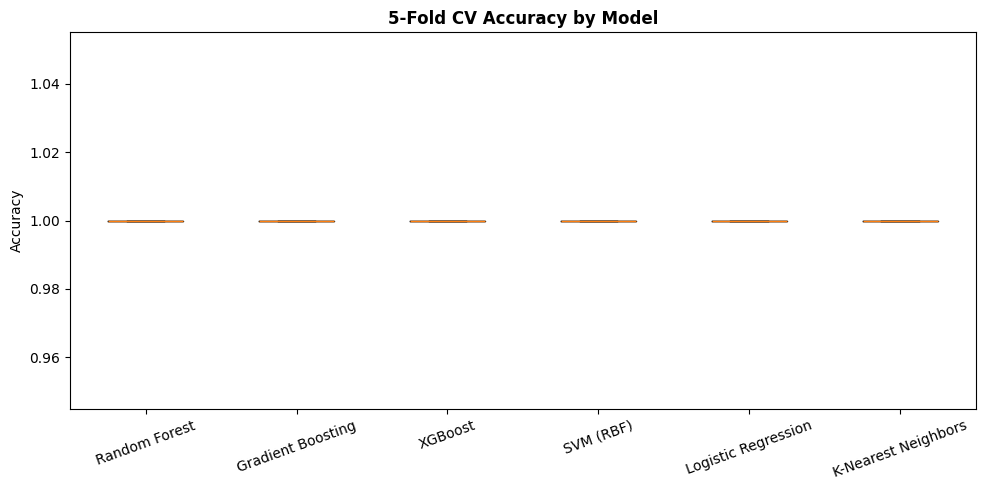

In [9]:
models = {
    'Random Forest'      : RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=RANDOM_STATE),
    'XGBoost'            : XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                          eval_metric='mlogloss'),
    'SVM (RBF)'          : SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('🔬 5-fold cross-validation on TRAINING split')
print('=' * 55)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv,
                              scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} mean={scores.mean():.4f}  std={scores.std():.4f}')

best_model_name = max(cv_results, key=lambda k: cv_results[k].mean())
print()
print(f'🏆 Best model by CV: {best_model_name}')

# Visualise
plt.figure(figsize=(10, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title('5-Fold CV Accuracy by Model', fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/05_model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

## Cell 8 — Feature Importance

Which of the 97 features actually separate your species? Particularly
relevant for the Sudu/Rathu Koboleela pair — if the top features are all
texture/venation (GLCM, Gabor, LBP) rather than gross shape, that's a good
sign the model isn't just leaning on overall leaf size.

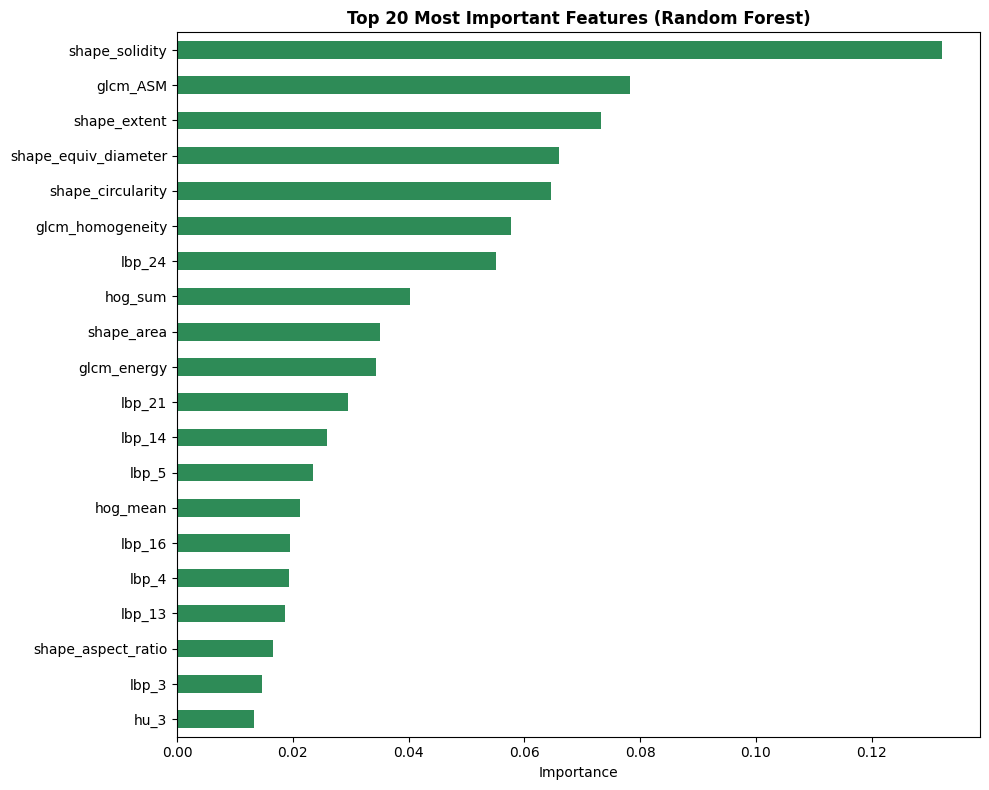

Top 10 features:
shape_solidity          0.132109
glcm_ASM                0.078293
shape_extent            0.073235
shape_equiv_diameter    0.065912
shape_circularity       0.064546
glcm_homogeneity        0.057673
lbp_24                  0.055109
hog_sum                 0.040301
shape_area              0.035143
glcm_energy             0.034311


In [10]:
rf_importance = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_importance.fit(X_train_scaled, y_train)

importances = pd.Series(rf_importance.feature_importances_, index=feature_cols_final)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top20[::-1].plot(kind='barh', color='seagreen')
plt.title('Top 20 Most Important Features (Random Forest)', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/05_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

print('Top 10 features:')
print(top20.head(10).to_string())

## Cell 9 — Hyperparameter Tuning (Best Model from Cell 7)

In [11]:
param_grids = {
    'Random Forest': {
        'n_estimators'     : [200, 300, 500],
        'max_depth'        : [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
    },
    'Gradient Boosting': {
        'n_estimators' : [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [2, 3, 4],
    },
    'XGBoost': {
        'n_estimators' : [100, 200, 300],
        'max_depth'    : [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
    },
    'SVM (RBF)': {
        'C'    : [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.001],
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights'    : ['uniform', 'distance'],
    },
}

base_model = models[best_model_name]
grid = GridSearchCV(base_model, param_grids[best_model_name],
                     cv=cv, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f'Tuning: {best_model_name}')
print(f'Best params      : {grid.best_params_}')
print(f'Best CV accuracy : {grid.best_score_:.4f}')

final_model = grid.best_estimator_

Tuning: Random Forest
Best params      : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV accuracy : 1.0000


## Cell 10 — Evaluate Tuned Model on Held-Out Validation Split

Validation accuracy: 1.0000

                 precision    recall  f1-score   support

Rathu_Koboleela       1.00      1.00      1.00       108
 Sudu_Koboleela       1.00      1.00      1.00       108

       accuracy                           1.00       216
      macro avg       1.00      1.00      1.00       216
   weighted avg       1.00      1.00      1.00       216



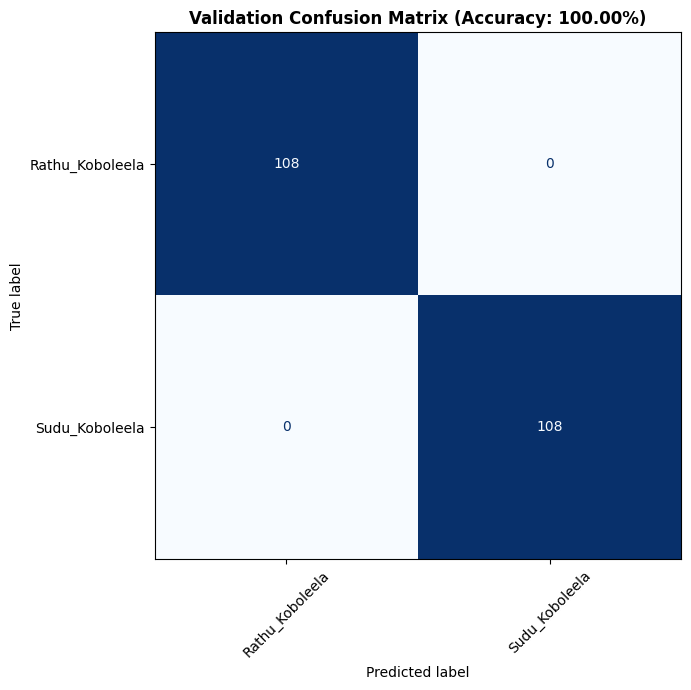

In [12]:
val_preds = final_model.predict(X_val_scaled)
val_acc   = accuracy_score(y_val, val_preds)

print(f'Validation accuracy: {val_acc:.4f}')
print()
print(classification_report(y_val, val_preds, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title(f'Validation Confusion Matrix (Accuracy: {val_acc:.2%})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/05_validation_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

## Cell 11 — Refit on the FULL Training Set

The validation split was only for unbiased model comparison. For the model
you actually deploy, refit the scaler + best model on ALL training data —
more data generally means a better final model.

In [13]:
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X)

final_model.fit(X_full_scaled, y_encoded)

print('✅ Final model retrained on the FULL training set')
print(f'   Model : {best_model_name}')
print(f'   Params: {grid.best_params_}')
print(f'   Samples used: {X.shape[0]}')

✅ Final model retrained on the FULL training set
   Model : Random Forest
   Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
   Samples used: 1080


## Cell 12 — Predict on the TRUE Test Set (No Labels)

In [14]:
X_test = test_df[feature_cols].copy()
X_test['view_top'] = (test_df['view'] == 'top').astype(int)

# Clean the same way as training data, using TRAIN medians (not test
# medians) so the test set is transformed consistently with training
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.fillna(train_medians)

X_test_scaled = scaler.transform(X_test)

test_preds_encoded = final_model.predict(X_test_scaled)
test_preds = label_encoder.inverse_transform(test_preds_encoded)

results_df = test_df[['filename', 'view']].copy()
results_df['predicted_species'] = test_preds

print(f'Predicted {len(results_df)} test images')
print()
print(results_df.head(10).to_string(index=False))

Predicted 20 test images

       filename   view predicted_species
Img_031_pre.jpg    top   Rathu_Koboleela
Img_032_pre.jpg    top   Rathu_Koboleela
Img_033_pre.jpg    top   Rathu_Koboleela
Img_034_pre.jpg    top   Rathu_Koboleela
Img_035_pre.jpg    top   Rathu_Koboleela
Img_031_pre.jpg bottom   Rathu_Koboleela
Img_032_pre.jpg bottom   Rathu_Koboleela
Img_033_pre.jpg bottom   Rathu_Koboleela
Img_034_pre.jpg bottom   Rathu_Koboleela
Img_035_pre.jpg bottom   Rathu_Koboleela


## Cell 13 — Score Against Hidden True Labels

🎯 FINAL TEST ACCURACY: 1.0000  (20/20)

                 precision    recall  f1-score   support

Rathu_Koboleela       1.00      1.00      1.00        10
 Sudu_Koboleela       1.00      1.00      1.00        10

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20



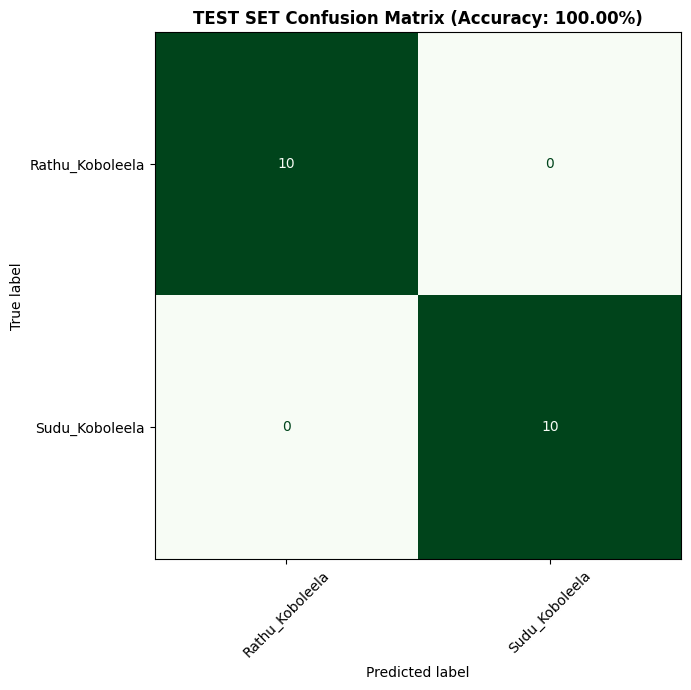

In [15]:
merged = results_df.merge(test_labels_df, on=['filename', 'view'], how='left')
merged['correct'] = merged['predicted_species'] == merged['true_label']

test_acc = merged['correct'].mean()
n_correct = int(merged['correct'].sum())

print(f'🎯 FINAL TEST ACCURACY: {test_acc:.4f}  ({n_correct}/{len(merged)})')
print()
print(classification_report(merged['true_label'], merged['predicted_species']))

labels_order = sorted(merged['true_label'].unique())
cm_test = confusion_matrix(merged['true_label'], merged['predicted_species'], labels=labels_order)
disp = ConfusionMatrixDisplay(cm_test, display_labels=labels_order)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap='Greens', xticks_rotation=45, colorbar=False)
plt.title(f'TEST SET Confusion Matrix (Accuracy: {test_acc:.2%})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{LOGS_PATH}/05_test_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

## Cell 14 — Per-Species & Per-View Breakdown

One overall accuracy number can hide a weak spot — this checks specifically
whether the morphologically similar pair (or any other pair) is being
confused, and whether one photo angle is more reliable than the other.

In [16]:
print('📋 PER-SPECIES ACCURACY')
per_species = merged.groupby('true_label')['correct'].agg(['mean', 'count'])
per_species.columns = ['accuracy', 'n_samples']
print(per_species.sort_values('accuracy').to_string())

print()
print('📋 PER-VIEW ACCURACY (top vs bottom)')
print(merged.groupby('view')['correct'].mean().to_string())

print()
print('⚠️  MISCLASSIFICATION PAIRS (true_label -> predicted)')
mistakes = merged[~merged['correct']]
if len(mistakes) > 0:
    confusion_pairs = (mistakes.groupby(['true_label', 'predicted_species'])
                        .size().sort_values(ascending=False))
    print(confusion_pairs.to_string())
else:
    print('No misclassifications! 🎉')

📋 PER-SPECIES ACCURACY
                 accuracy  n_samples
true_label                          
Rathu_Koboleela       1.0         10
Sudu_Koboleela        1.0         10

📋 PER-VIEW ACCURACY (top vs bottom)
view
bottom    1.0
top       1.0

⚠️  MISCLASSIFICATION PAIRS (true_label -> predicted)
No misclassifications! 🎉


## Cell 15 — Save Model Artifacts

In [17]:
joblib.dump(final_model,        os.path.join(MODEL_PATH, 'species_classifier.pkl'))
joblib.dump(scaler,             os.path.join(MODEL_PATH, 'scaler.pkl'))
joblib.dump(label_encoder,      os.path.join(MODEL_PATH, 'label_encoder.pkl'))
joblib.dump(feature_cols_final, os.path.join(MODEL_PATH, 'feature_columns.pkl'))

print('✅ Model artifacts saved:')
print(f'   {MODEL_PATH}/species_classifier.pkl')
print(f'   {MODEL_PATH}/scaler.pkl')
print(f'   {MODEL_PATH}/label_encoder.pkl')
print(f'   {MODEL_PATH}/feature_columns.pkl')

✅ Model artifacts saved:
   /content/drive/MyDrive/VedaVision/dataset/models/species_classifier.pkl
   /content/drive/MyDrive/VedaVision/dataset/models/scaler.pkl
   /content/drive/MyDrive/VedaVision/dataset/models/label_encoder.pkl
   /content/drive/MyDrive/VedaVision/dataset/models/feature_columns.pkl


## Cell 16 — Final Summary

In [18]:
print('📊 FINAL SUMMARY')
print('=' * 60)
print(f'Best model          : {best_model_name}')
print(f'Best params          : {grid.best_params_}')
print(f'CV accuracy (tuned)  : {grid.best_score_:.4f}')
print(f'Validation accuracy  : {val_acc:.4f}')
print(f'TEST accuracy        : {test_acc:.4f}')
print('=' * 60)
print()
print('📁 Model saved to:', MODEL_PATH)
print()
print('📋 To use this model on a NEW leaf photo:')
print('   1. Run it through 02_Preprocessing.ipynb')
print('   2. Extract features with 04_Feature_Extraction.ipynb functions')
print('   3. Add the view_top one-hot column the same way as Cell 5')
print('   4. Scale with the saved scaler.pkl')
print('   5. Predict with species_classifier.pkl')
print('   6. Decode the prediction with label_encoder.pkl')
print()
print('💡 If accuracy on the similar-looking species pair is weak (see')
print('   Cell 14), that\'s a feature-extraction problem, not a model')
print('   problem — more tuning here won\'t fix it. Worth revisiting which')
print('   features actually separate that pair (Cell 8) before assuming')
print('   the model needs to be more complex.')

📊 FINAL SUMMARY
Best model          : Random Forest
Best params          : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
CV accuracy (tuned)  : 1.0000
Validation accuracy  : 1.0000
TEST accuracy        : 1.0000

📁 Model saved to: /content/drive/MyDrive/VedaVision/dataset/models

📋 To use this model on a NEW leaf photo:
   1. Run it through 02_Preprocessing.ipynb
   2. Extract features with 04_Feature_Extraction.ipynb functions
   3. Add the view_top one-hot column the same way as Cell 5
   4. Scale with the saved scaler.pkl
   5. Predict with species_classifier.pkl
   6. Decode the prediction with label_encoder.pkl

💡 If accuracy on the similar-looking species pair is weak (see
   Cell 14), that's a feature-extraction problem, not a model
   problem — more tuning here won't fix it. Worth revisiting which
   features actually separate that pair (Cell 8) before assuming
   the model needs to be more complex.
